### Loading training data

In [1]:
%%time
import os
import json
import sys
from pathlib import Path

import numpy as np

if Path.cwd().name == "plotting":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from eval.paths import DATA_ROOT

SAVE_DIR = DATA_ROOT
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")
wait_sv = targets["wait_sv"]
qs = targets["qs"]

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)
XSUB_COLS = meta["XSUB_COLS"]
NCAT_SUB = meta["NCAT_SUB"]

# The experiment split, as eval/splits.py builds it (design 8020) and
# experiment-setup.ipynb saved it. E2 is split on when the wait becomes known
# (execution start) and keeps every job with a measured wait.
SPLIT = np.load(os.path.join(SAVE_DIR, "splits_8020.npz"))
with open(os.path.join(SAVE_DIR, "splits_meta.json")) as f:
    SPLIT_META = json.load(f)

# Each arm's test set, plus the shared out-of-time set. The temporal arm's test set IS
# the out-of-time set under this design.
TEST_IDX = {"random": SPLIT["e2__random_test"], "temporal": SPLIT["e2__oot_test"],
            "oot": SPLIT["e2__oot_test"]}

print(f"working directory: {os.getcwd()}")
print(f"Loaded Xsub {Xsub.shape} | split {SPLIT_META['design']}, cutoff "
      f"{SPLIT_META['cutoff_utc']}, validation date V {SPLIT_META['val_start_utc']}")

working directory: /home/amaustin/Research/fife-batch-jobs/scripts
Loaded Xsub (64088358, 26) | split 8020, cutoff 2025-07-10 00:00, validation date V 2025-06-24 00:00
CPU times: user 11.6 s, sys: 393 ms, total: 12 s
Wall time: 4.3 s


#### Features

In [2]:
print(f"Xsub {Xsub.shape} -- submit-time features (E2 predicts before the job is matched):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: log_idle_queue_depth (submitted-not-started at submit),")
print("  log_camp_trail_wait (campaign's trailing mean wait), log_*_running (running counts)")
print("target: wait_log = log1p(wait seconds), from submission to first execution start")

Xsub (64088358, 26) -- submit-time features (E2 predicts before the job is matched):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignType
  [ 6] TestLaunch
  [ 7] JobsubGroup
  [ 8] Image
  [ 9] BlacklistSites
  [10] RequestCpus (std)
  [11] RequestDisk (std)
  [12] RequestMemory (std)
  [13] RequestSlots (std)
  [14] ExecutableSize (std)
  [15] TransferInputMB (std)
  [16] ExpectedLifetime (std)
  [17] TotalSubmitProcs (std)
  [18] sin_hour@submit
  [19] cos_hour@submit
  [20] sin_wday@submit
  [21] cos_wday@submit
  [22] log_idle_queue_depth
  [23] log_camp_trail_wait
  [24] log_total_running@submit
  [25] log_pilots_running@submit

state variables: log_idle_queue_depth (submitted-not-started at submit),
  log_camp_trail_wait (campaign's trailing mean wait), log_*_running (running counts)
target: wait_log = log1p(wait seconds), from submission to first execution start


#### Experiment population
Every job with a measured wait, from the 8020 split; each arm's fit / validation / test sets, median wait and queueing-regime mix.

In [2]:
# E2 predicts the wait of every job that has one (it started). Each arm's fit /
# validation / test sets, with the median wait and the share of jobs in each queueing
# regime (the bins the per-regime figure below reports).
import pandas as pd
from eval.helper import WAIT_REGIMES

E2_SETS = {
    "random": {"fit": SPLIT["e2__random__fit"], "val": SPLIT["e2__random__val"],
               "test": SPLIT["e2__random_test"], "oot": SPLIT["e2__oot_test"]},
    "temporal": {"fit": SPLIT["e2__temporal__fit"], "val": SPLIT["e2__temporal__val"],
                 "test": SPLIT["e2__oot_test"], "oot": SPLIT["e2__oot_test"]},
}
rows = []
for arm, sets in E2_SETS.items():
    for name, i in sets.items():
        w = np.asarray(wait_sv[i], dtype=np.float64)
        rec = {"arm": arm, "set": name, "jobs": len(i), "median wait (min)": np.nanmedian(w) / 60}
        for reg, lo, hi in WAIT_REGIMES:
            rec[reg] = ((w >= lo) & (w < hi)).mean()
        rows.append(rec)
fmt = {"jobs": "{:,}", "median wait (min)": "{:.1f}"} | {r: "{:.1%}" for r, _, _ in WAIT_REGIMES}
display(pd.DataFrame(rows).style.format(fmt))
print("Regimes: inst < 2 min, turn 2-45 min, prov 45 min - 1 day, park > 1 day. The temporal "
      "arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.")

,arm,set,jobs,median wait (min),inst,turn,prov,park
0,random,fit,"36,587,590",23.1,17.0%,44.6%,36.0%,2.4%
1,random,val,"4,001,968",23.1,17.0%,44.6%,36.0%,2.4%
2,random,test,"4,510,891",23.1,17.0%,44.6%,36.0%,2.4%
3,random,oot,"11,303,119",38.2,11.2%,42.1%,44.3%,2.5%
4,temporal,fit,"36,587,590",21.8,17.5%,45.1%,34.9%,2.5%
5,temporal,val,"4,001,968",41.4,11.8%,39.9%,46.4%,1.9%
6,temporal,test,"11,303,119",38.2,11.2%,42.1%,44.3%,2.5%
7,temporal,oot,"11,303,119",38.2,11.2%,42.1%,44.3%,2.5%


Regimes: inst < 2 min, turn 2-45 min, prov 45 min - 1 day, park > 1 day. The temporal arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.


### Loading wait-time models and feature importances

In [3]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances
from eval.paths import model_dir

# Tree importances come from the saved regressors (split gain). Neural models are
# scored by permutation on a random 200,000-job sample of the out-of-time test set --
# jobs neither arm trained on -- as the drop in R^2 on log1p(wait), the models' target
# scale; TabNet by attention mass. The same sample is used for both arms' models.
_oot = E2_SETS["temporal"]["oot"]
_rng = np.random.default_rng(0)
eval_idx = np.sort(_rng.choice(_oot, size=min(200_000, len(_oot)), replace=False))
X_eval = np.ascontiguousarray(Xsub[eval_idx], dtype=np.float32)
y_eval = np.log1p(np.maximum(np.asarray(wait_sv[eval_idx], dtype=np.float64), 0)).astype(np.float32)
print(f"importance sample: {len(eval_idx):,} OOT jobs, median wait "
      f"{np.median(np.expm1(y_eval)) / 60:.1f} min")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _models = ["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"]
    E2_IMP = load_saved_importances(
        models=_models,
        model_dirs=[model_dir("e2", m, create=False) for m in _models],
        exp_tag=None,
        splits=["random", "temporal"],
        n_feats=len(XSUB_COLS),
        X_eval=X_eval,
        y_eval=y_eval,
        kind="reg",
    )

importance sample: 200,000 OOT jobs, median wait 38.2 min
[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/ssd/amaustin/models/e2/xgboost/xgboost_reg_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/ssd/amaustin/models/e2/xgboost/xgboost_reg_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/ssd/amaustin/models/e2/lightgbm/lightgbm_reg_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/ssd/amaustin/models/e2/lightgbm/lightgbm_reg_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/ssd/amaustin/models/e2/catboost/catboost_reg_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/ssd/amaustin/models/e2/catboost/catboost_reg_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
[Loaded TabNet Model] tabnet     (random  ) computed feature importances successfully.
[Loaded TabNet Model] tabnet     (temporal) computed 

## Feature Importance
### Random split

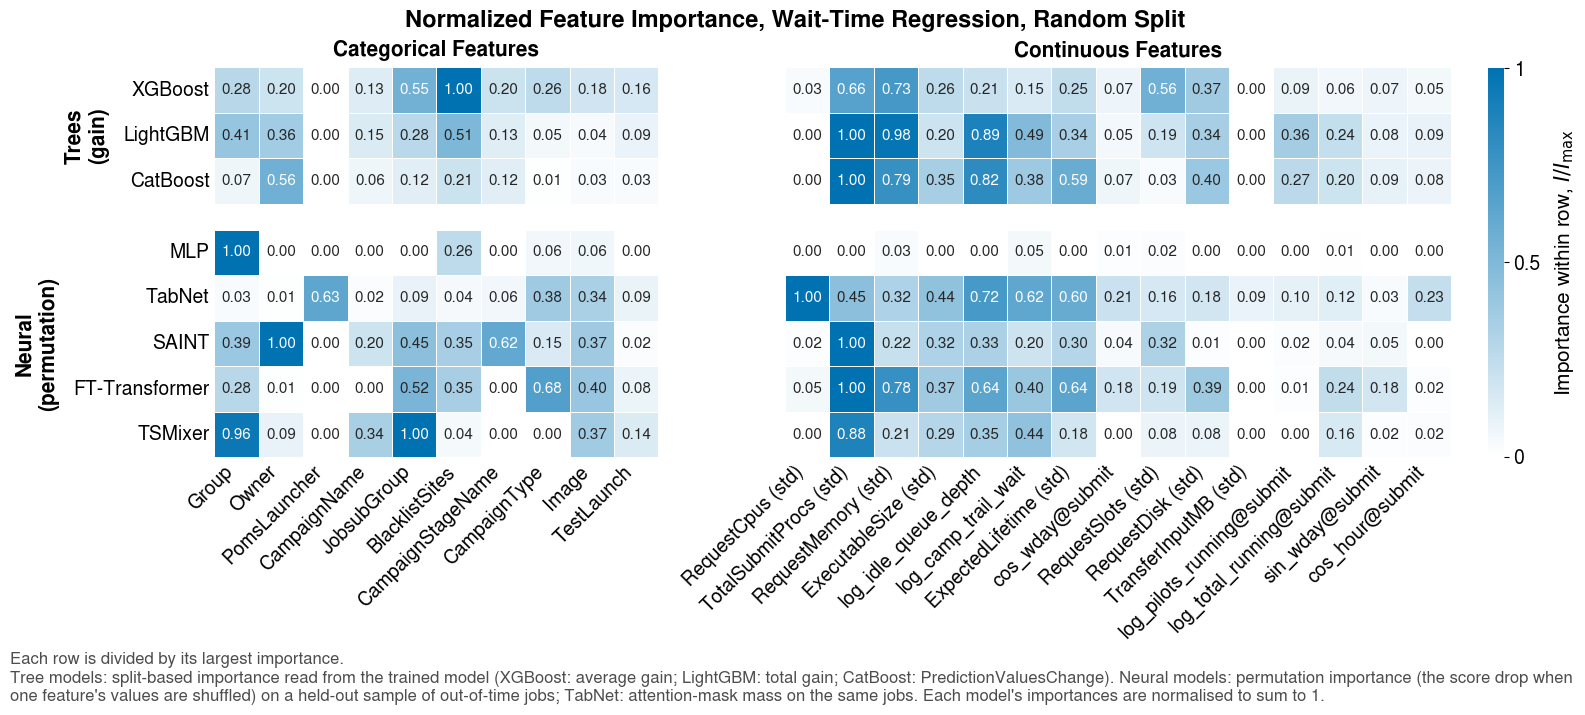

In [4]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E2_IMP,
    feats=XSUB_COLS,
    n_cat=NCAT_SUB,
    split_key="random",
    exp="e2",
    title="Normalized Feature Importance, Wait-Time Regression, Random Split",
    output_prefix="feature_split_imp_heatmap",
)

### Temporal split

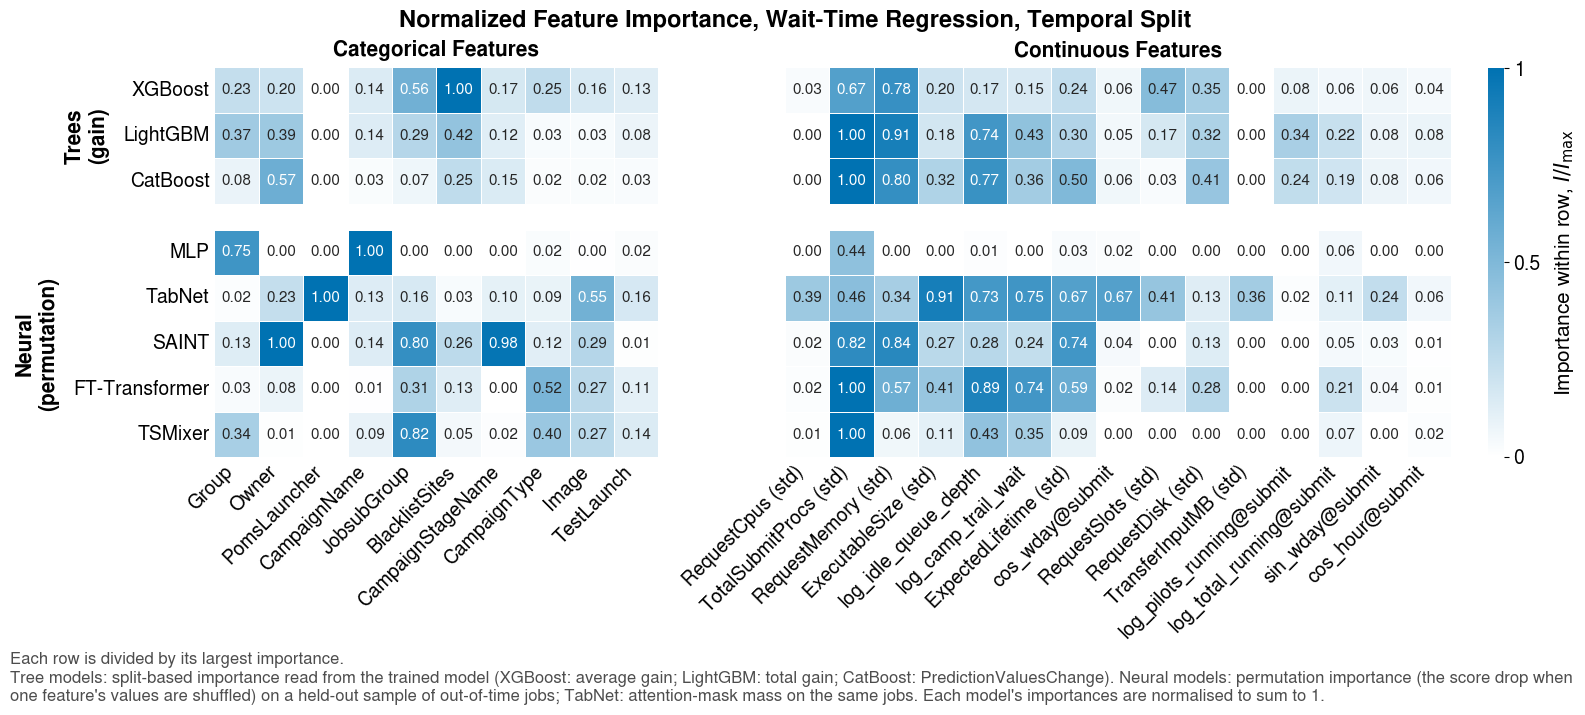

In [5]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E2_IMP,
    feats=XSUB_COLS,
    n_cat=NCAT_SUB,
    split_key="temporal",
    exp="e2",
    title="Normalized Feature Importance, Wait-Time Regression, Temporal Split",
    output_prefix="feature_split_imp_heatmap",
)

### Feature gain shift (random -> temporal)

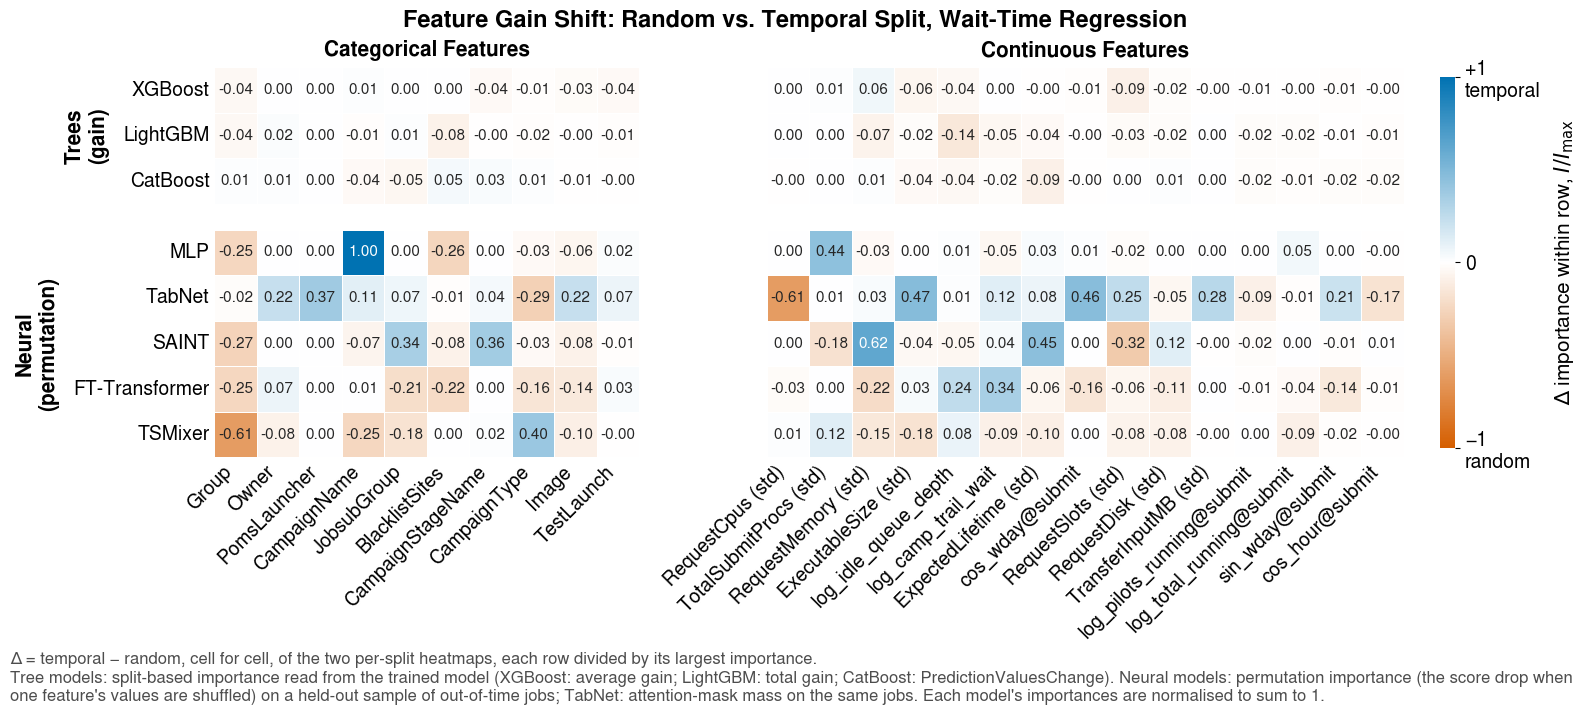

,Group,Owner,PomsLauncher,CampaignName,JobsubGroup,BlacklistSites,CampaignStageName,CampaignType,Image,TestLaunch,...,log_camp_trail_wait,ExpectedLifetime (std),cos_wday@submit,RequestSlots (std),RequestDisk (std),TransferInputMB (std),log_pilots_running@submit,log_total_running@submit,sin_wday@submit,cos_hour@submit
XGBoost,-0.043611,0.001026,0.000000,0.008917,0.004480,0.000000,-0.038422,-0.007980,-0.026218,-0.037175,...,0.003023,-0.003864,-0.011197,-0.087678,-0.022565,-0.000128,-0.006287,-0.002200,-0.008951,-0.003387
LightGBM,-0.040067,0.020144,0.000000,-0.012168,0.014950,-0.080719,-0.000438,-0.015407,-0.004867,-0.008668,...,-0.051053,-0.037939,-0.000890,-0.026658,-0.022192,0.000001,-0.020468,-0.015708,-0.006764,-0.009355
CatBoost,0.013606,0.013545,0.000000,-0.036238,-0.050734,0.046502,0.029839,0.011933,-0.006549,-0.002880,...,-0.019643,-0.087958,-0.004987,0.000383,0.011021,0.000000,-0.023344,-0.010978,-0.019115,-0.018396
MLP,-0.247283,0.000000,0.000000,1.000000,0.000000,-0.257054,0.000000,-0.033098,-0.056498,0.021206,...,-0.048286,0.030163,0.009875,-0.022910,0.000000,0.000006,0.000000,0.049707,0.000000,-0.002239
TabNet,-0.016412,0.219822,0.370473,0.110104,0.068222,-0.008508,0.044934,-0.288190,0.219310,0.074988,...,0.124120,0.077307,0.462100,0.247380,-0.052626,0.275145,-0.086650,-0.010402,0.207172,-0.172909
SAINT,-0.265706,0.004443,0.000000,-0.066218,0.342369,-0.081670,0.361115,-0.032120,-0.079906,-0.008679,...,0.038737,0.448296,0.002135,-0.321412,0.120509,-0.000074,-0.021691,0.002501,-0.014542,0.007328
FT-Transformer,-0.249178,0.070328,0.000000,0.005385,-0.205365,-0.220391,0.000000,-0.157487,-0.136549,0.027894,...,0.337222,-0.057478,-0.162216,-0.058968,-0.106471,0.000295,-0.014066,-0.035550,-0.139950,-0.008115
TSMixer,-0.614111,-0.082473,0.000000,-0.245483,-0.178709,0.003796,0.015598,0.396901,-0.098026,-0.002226,...,-0.086637,-0.096143,0.000000,-0.075940,-0.080957,-0.000224,0.000000,-0.086819,-0.015541,-0.003934


In [6]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

# One table, each row scaled by its own max |delta|. Trees and neural models sit in
# separate row blocks: split gain and permutation importance are different quantities,
# so the per-row scaling does not put them on a common footing (see the figure note).
imp_diff_heatmap(
    imp_dict=E2_IMP,
    feats=XSUB_COLS,
    n_cat=NCAT_SUB,
    exp="e2",
    title="Feature Gain Shift: Random vs. Temporal Split, Wait-Time Regression",
    output_prefix="imp_diff_heatmap",
)

## Performance evaluation
### Wait-time results: load, aggregate across seeds, filter
Builds `df_wait` (temporal) and `df_rand` (random) from the harness results (`results/wait_time/<model>.json`). The figures below only draw what this produces.

In [7]:
import json
import numpy as np
import pandas as pd
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import (MODEL_DISPLAY_NAMES, PREFERRED_MODEL_ORDER,
                         WAIT_REGIMES)

RESULTS_PATH = "results/wait_time/"   # one <model>.json per model
SPLIT = "temporal"
CONTRAST_SPLIT = "random"
# A model whose r2_log is negative beyond seed noise does worse than predicting
# the mean wait for every
# job, so its per-bin errors describe a model no one would deploy. Flip to
# False to keep them in the figures for diagnostic purposes.
DROP_NEGATIVE_R2 = False   # plot every model, including negative R2(log)

# Which seed each row reports. "mean" averages every seed and records the SD;
# "best" takes the seed that scored highest on PRIMARY and reports ALL of that
# run's metrics, so a row describes one model that existed rather than a
# per-metric maximum. DROP_NEGATIVE_R2 then tests whichever value is reported.
SEED_PICK = "mean"          # "mean" | "best"
PRIMARY = "r2_log"

# results/wait_time/<model>.json is APPEND-ONLY, so it still holds entries from runs
# that predate the current feature matrices and the fit-derived error bins. Rather
# than naming the models that have been rerun -- a list that goes stale the moment
# another finishes -- select on whether an entry carries the new regime keys. An old
# entry has only the legacy <10m / 10m-2h / >2h bins and is skipped automatically.
REGIME_KEYS = [f"mae_{name}" for name, _, _ in WAIT_REGIMES]
REQUIRE_CURRENT_BINS = True

# Entries are keyed "<split>" for a default-seed run and "<split>__seed<n>" for a
# multi-seed one, so a model may carry both from different runs. The file has no
# timestamps, so recency has to be inferred from the key shape: the current protocol
# always runs --seeds 0,1,2, which means a PLAIN key can only have come from an older
# single-seed run. Prefer the seeded entries.
#
# This preference used to run the other way, from a round where the trees were rerun
# at the default seed AFTER their seeded entries. That is no longer true and the rule
# had gone stale in the worst way: it was showing the trees' pre-holdout-fix numbers
# (xgboost 74 s) next to the neural models' post-fix numbers (seeded, 102 s), i.e.
# comparing two different training protocols inside one figure.
PREFER_SEEDED = True

from eval.helper import load_results
_raw = load_results("wait_time")


def _seed_keys(splits, split):
    return [k for k in splits
            if k == split or k.startswith(f"{split}__seed")]


def build_split_frame(split, verbose=True):
    """Mean (and SD) across seeds for every model carrying the current bins on `split`.

    Returns a frame indexed by display name in PREFERRED_MODEL_ORDER. `n_seeds` records
    how many runs went into each row; `<key>__sd` is the sample SD across them, NaN for
    a single-seed row so the figures draw no bar rather than a zero-length one.
    """
    rows, stale, partial, mixed = [], [], [], []
    for key, splits in _raw.items():
        name = MODEL_DISPLAY_NAMES.get(key, key)
        cand = _seed_keys(splits, split)
        current = [k for k in cand
                   if not REQUIRE_CURRENT_BINS or all(m in splits[k] for m in REGIME_KEYS)]
        if not current:
            if cand:
                stale.append(name)
            continue
        seeded = [k for k in current if k != split]
        if PREFER_SEEDED and seeded and split in current:
            mixed.append(f"{name} (kept {len(seeded)} seeded, ignored default-seed entry)")
            current = seeded
        elif not PREFER_SEEDED and split in current and len(current) > 1:
            mixed.append(f"{name} (kept default-seed run, ignored "
                         f"{len(current) - 1} seeded entr"
                         f"{'y' if len(current) == 2 else 'ies'})")
            current = [split]
        def _numeric(d):
            return {k: v for k, v in d.items()
                    if isinstance(v, (int, float)) and not isinstance(v, bool)}

        # Top-level metrics, plus the out-of-time block flattened to "oot.<metric>",
        # which is what the dotted Random/out-of-time bars read. Runs predating the
        # OOT arm simply lack those keys and drop out rather than mixing arms.
        def _flat(d):
            out = dict(_numeric(d))
            out.update({f"oot.{k}": v for k, v in _numeric(d.get("oot") or {}).items()})
            return out

        flats = {c: _flat(splits[c]) for c in current}
        nums = sorted({k for f in flats.values() for k in f})
        agg = {}
        if SEED_PICK == "best":
            scored = [c for c in current if PRIMARY in flats[c]]
            pick = max(scored, key=lambda c: flats[c][PRIMARY]) if scored else current[0]
            for k in nums:
                agg[k] = float(flats[pick][k]) if k in flats[pick] else float("nan")
                agg[f"{k}__sd"] = float("nan")   # one run: no spread to draw
            agg["seed_picked"] = pick
        else:
            for k in nums:
                vals = [flats[c][k] for c in current if k in flats[c]]
                if not vals:
                    continue
                agg[k] = float(np.mean(vals))
                agg[f"{k}__sd"] = (float(np.std(vals, ddof=1)) if len(vals) > 1
                                   else float("nan"))
        agg["n_seeds"] = len(current)
        rows.append({"model": name, **agg})
        if len(current) not in (1, 3, 5):
            partial.append(f"{name} ({len(current)} seeds)")

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"no entries with the current bins for split '{split}' -- "
                           f"rerun the harness, or set REQUIRE_CURRENT_BINS = False")

    # Negative BEYOND seed noise: mean + 1 SD still below zero. Testing the point
    # estimate alone excluded SAINT at -0.016 +/- 0.099, which is not distinguishable
    # from zero, and took it out of every downstream figure since those read
    # df_wait.index.
    _upper = df["r2_log"] + df.get("r2_log__sd", 0.0).fillna(0.0)
    dropped = df.loc[_upper < 0, "model"].tolist()
    if DROP_NEGATIVE_R2 and dropped:
        # Remove on the same test that produced `dropped`, or the printed provenance
        # and the figure disagree.
        df = df[~df["model"].isin(dropped)]

    # Ordered by PREFERRED_MODEL_ORDER (trees first, then neural), matching the README
    # and run_sweep.sh, so every figure and table can be read position by position.
    # Anything not in that list sorts last, alphabetically.
    order = [MODEL_DISPLAY_NAMES.get(k, k) for k in PREFERRED_MODEL_ORDER]
    rank = {n: i for i, n in enumerate(dict.fromkeys(order))}
    df = (df.assign(_rank=df["model"].map(lambda m: rank.get(m, len(rank))))
            .sort_values(["_rank", "model"])
            .drop(columns="_rank")
            .set_index("model"))

    if verbose:
        print(f"[{split}] {len(df)} model(s)")
        print("  seeds per model: "
              + ", ".join(f"{m}={int(n)}" for m, n in zip(df.index, df["n_seeds"])))
        if stale:
            print(f"  skipped (only pre-regeneration entries): {', '.join(sorted(set(stale)))}")
        if partial:
            print(f"  INCOMPLETE seed sets: {', '.join(sorted(set(partial)))}")
        if mixed:
            print(f"  mixed run types: {'; '.join(sorted(set(mixed)))}")
        if dropped:
            kept = "excluded" if DROP_NEGATIVE_R2 else "kept"
            print(f"  r2_log < 0 ({kept}): {', '.join(dropped)}")
    return df


print(f"{RESULTS_PATH}")
df_wait = build_split_frame(SPLIT)
# The contrast line is reindexed onto the temporal model list so both lines share an
# x-axis. A model the temporal split dropped (r2_log < 0) stays dropped in both; a
# model with no usable random entry becomes NaN and simply breaks its line.
df_rand = build_split_frame(CONTRAST_SPLIT).reindex(df_wait.index)
_missing = df_rand.index[df_rand["r2_log"].isna()].tolist()
if _missing:
    print(f"  [{CONTRAST_SPLIT}] no usable entry for: {', '.join(_missing)}")

_cols = ["r2_log", "median_ae_s", "mae_raw_s", "within2x", "n_seeds"]
display(pd.concat({SPLIT: df_wait[_cols], CONTRAST_SPLIT: df_rand[_cols]},
                  axis=1).round(3))


results/wait_time/
[temporal] 8 model(s)
  seeds per model: XGBoost=3, LightGBM=3, CatBoost=3, MLP=3, TabNet=3, SAINT=3, FT-Transformer=3, TSMixer=3
  r2_log < 0 (kept): FT-Transformer, LightGBM, MLP, SAINT, TabNet
[random] 8 model(s)
  seeds per model: XGBoost=3, LightGBM=3, CatBoost=3, MLP=3, TabNet=3, SAINT=3, FT-Transformer=3, TSMixer=3


temporal                                            random  \
                 r2_log median_ae_s     mae_raw_s within2x n_seeds r2_log   
model                                                                       
XGBoost          -0.031    2154.761  1.189586e+04    0.255       3  0.856   
LightGBM         -0.059    2131.329  1.205305e+04    0.253       3  0.855   
CatBoost          0.137    2119.913  1.122389e+04    0.269       3  0.770   
MLP              -0.347    2025.743  1.219084e+04    0.230       3  0.835   
TabNet           -0.174    2423.597  1.485689e+13    0.243       3  0.778   
SAINT            -0.240    2625.677  1.481701e+04    0.228       3  0.755   
FT-Transformer   -0.357    2814.906  1.339822e+04    0.232       3  0.857   
TSMixer          -0.038    3150.665  1.319857e+04    0.229       3  0.687   

                                                       
               median_ae_s mae_raw_s within2x n_seeds  
model                                                  
XGBoost            548.350  4931.632    0.656       3  
LightGBM           551.295  4972.009    0.654       3  
CatBoost           721.877  7107.594    0.531       3  
MLP                603.952  6909.144    0.561       3  
TabNet             705.553  6673.077    0.566       3  
SAINT              811.811  7539.733    0.524       3  
FT-Transformer     556.120  4917.644    0.652       3  
TSMixer            990.070  8817.887    0.466       3

### Wait-time results table
Random vs Temporal split, mean ± SD over seeds; also written as LaTeX to `output/wait_time_table.tex`.

In [3]:
# Paper table (tab:results_wait_overall): mean +/- sample SD over seeds. Random Split =
# the random arm on its own test set; Temporal Split = the temporal arm on its test set,
# the out-of-time set. Best per column in bold. Shown here and written as LaTeX to
# output/wait_time_table.tex. Models without results yet are left out.
import os
import pandas as pd
from eval.helper import load_results, aggregate_seeds

TABLE_MODELS = [
    ("xgboost", r"XGBoost~\cite{chen_xgboost_2016}"),
    ("lightgbm", r"LightGBM~\cite{ke_lightgbm}"),
    ("catboost", r"CatBoost~\cite{catboost}"),
    ("mlp", "MLP"),
    ("ft", r"FT-Transformer~\cite{ft_transformer}"),
    ("tabnet", r"TabNet~\cite{arik_tabnet_2021}"),
    ("saint", r"SAINT~\cite{saint}"),
    ("hierarchical", r"TROUT~\cite{lovell_hierarchical_2024}"),
    ("tsmixer", r"TSMixer~\cite{chen_tsmixer_2023}"),
]
# (metric key, header, better, number format)
TABLE_COLS = [("r2_log", r"$\uparrow$ $\mathbf{R^2(\log)}$", max, "{:.3f}"),
              ("median_ae_s", r"$\downarrow$ \textbf{Med-AE (s)}", min, "{:.0f}"),
              ("within2x", r"$\uparrow$ \textbf{within-$2\times$}", max, "{:.3f}")]
ARMS = [("random", "Random Split"), ("temporal", "Temporal Split")]

_res = load_results("wait_time")
_stats = {}
for mk, _ in TABLE_MODELS:
    for arm, _ in ARMS:
        runs = [v for k, v in _res.get(mk, {}).items() if k.startswith(f"{arm}__seed")]
        if runs:
            agg = aggregate_seeds(runs)
            _stats[mk, arm] = {c: (agg[c]["mean"], agg[c]["std"], agg[c]["n"]) for c, *_ in TABLE_COLS}
_present = [(mk, name) for mk, name in TABLE_MODELS if any((mk, a) in _stats for a, _ in ARMS)]
_best = {}
for arm, _ in ARMS:
    for c, _, better, fmt in TABLE_COLS:
        vals = [float(fmt.format(_stats[mk, arm][c][0])) for mk, _ in _present if (mk, arm) in _stats]
        _best[arm, c] = better(vals) if vals else None

def _cell(mk, arm, c, fmt, latex):
    if (mk, arm) not in _stats:
        return "--"
    mu, sd, _n = _stats[mk, arm][c]
    txt = f"{fmt.format(mu)} \\pm {fmt.format(sd)}" if latex else f"{fmt.format(mu)} ± {fmt.format(sd)}"
    bold = float(fmt.format(mu)) == _best[arm, c]
    if latex:
        return f"$\\mathbf{{{txt}}}$" if bold else f"${txt}$"
    return f"**{txt}**" if bold else txt

# Notebook view
_rows = {name.split("~")[0]: {(alabel, hdr.split("textbf{")[-1].rstrip("}").replace("$", "") if "textbf" in hdr else c): _cell(mk, arm, c, fmt, False)
                              for arm, alabel in ARMS for c, hdr, _, fmt in TABLE_COLS}
         for mk, name in _present}
_df = pd.DataFrame(_rows).T
_df.columns = pd.MultiIndex.from_tuples([(alabel, lab) for alabel in [a for _, a in ARMS]
                                         for lab in ("R2(log)", "Med-AE (s)", "within-2x")])
display(_df)
print("seeds per model/arm:", {f"{mk}/{arm}": v[TABLE_COLS[0][0]][2] for (mk, arm), v in _stats.items()})

# LaTeX, in the layout of the paper's table
_lines = [r"\begin{table*}[ht]", r"\centering",
          r"\caption{Multi-seed averaged performance metrics ($\text{Mean} \pm \text{Std}$) for "
          r"queue wait time prediction comparing Random and Temporal splits across all models.}",
          r"\setlength{\tabcolsep}{3.5pt}", r"\begin{tabular}{lccc|ccc}", r"\hline",
          r"& \multicolumn{3}{c|}{\textbf{Random Split}} & \multicolumn{3}{c}{\textbf{Temporal Split}} \\",
          r"\cline{2-4} \cline{5-7}",
          r"\textbf{Model} & " + " & ".join(h for _ in ARMS for _, h, *_ in TABLE_COLS) + r" \\",
          r"\hline"]
_w = max(len(n) for _, n in _present) if _present else 0
for mk, name in _present:
    _lines.append(f"{name:<{_w}} & " + " & ".join(_cell(mk, arm, c, fmt, True)
                                                   for arm, _ in ARMS for c, _, _, fmt in TABLE_COLS) + r" \\")
_lines += [r"\hline", r"\end{tabular}", r"\label{tab:results_wait_overall}", r"\end{table*}"]
os.makedirs("output", exist_ok=True)
with open("output/wait_time_table.tex", "w") as f:
    f.write("\n".join(_lines) + "\n")
print("\n".join(_lines))

Random Split                                  \
                          R2(log)   Med-AE (s)          within-2x   
XGBoost             0.856 ± 0.000  **548 ± 3**  **0.656 ± 0.001**   
LightGBM            0.855 ± 0.001      551 ± 2      0.654 ± 0.001   
CatBoost            0.770 ± 0.002      722 ± 2      0.531 ± 0.003   
MLP                 0.835 ± 0.006     604 ± 15      0.561 ± 0.019   
FT-Transformer  **0.857 ± 0.002**      556 ± 5      0.652 ± 0.009   
TabNet              0.778 ± 0.001     706 ± 15      0.566 ± 0.004   
SAINT               0.755 ± 0.038    812 ± 108      0.524 ± 0.040   
TSMixer             0.687 ± 0.008     990 ± 88      0.466 ± 0.009   

                   Temporal Split                                    
                          R2(log)     Med-AE (s)          within-2x  
XGBoost            -0.031 ± 0.057      2155 ± 38      0.255 ± 0.004  
LightGBM           -0.059 ± 0.053      2131 ± 29      0.253 ± 0.001  
CatBoost        **0.137 ± 0.020**      2120 ± 74  **0.269 ± 0.006**  
MLP                -0.347 ± 0.096  **2026 ± 86**      0.230 ± 0.005  
FT-Transformer     -0.357 ± 0.114      2815 ± 93      0.232 ± 0.014  
TabNet             -0.174 ± 0.104     2424 ± 203      0.243 ± 0.015  
SAINT              -0.240 ± 0.188     2626 ± 173      0.228 ± 0.009  
TSMixer            -0.038 ± 0.101     3151 ± 150      0.229 ± 0.015

seeds per model/arm: {'xgboost/random': 3, 'xgboost/temporal': 3, 'lightgbm/random': 3, 'lightgbm/temporal': 3, 'catboost/random': 3, 'catboost/temporal': 3, 'mlp/random': 3, 'mlp/temporal': 3, 'ft/random': 3, 'ft/temporal': 3, 'tabnet/random': 3, 'tabnet/temporal': 3, 'saint/random': 3, 'saint/temporal': 3, 'tsmixer/random': 3, 'tsmixer/temporal': 3}
\begin{table*}[ht]
\centering
\caption{Multi-seed averaged performance metrics ($\text{Mean} \pm \text{Std}$) for queue wait time prediction comparing Random and Temporal splits across all models.}
\setlength{\tabcolsep}{3.5pt}
\begin{tabular}{lccc|ccc}
\hline
& \multicolumn{3}{c|}{\textbf{Random Split}} & \multicolumn{3}{c}{\textbf{Temporal Split}} \\
\cline{2-4} \cline{5-7}
\textbf{Model} & $\uparrow$ $\mathbf{R^2(\log)}$ & $\downarrow$ \textbf{Med-AE (s)} & $\uparrow$ \textbf{within-$2\times$} & $\uparrow$ $\mathbf{R^2(\log)}$ & $\downarrow$ \textbf{Med-AE (s)} & $\uparrow$ \textbf{within-$2\times$} \\
\hline
XGBoost~\cite{chen_xgboost

### Wait-time error by queueing regime
Temporal, OOT; Random, Random; and Random, OOT in one figure.

Test samples: out-of-time 11,303,119 | random test set 4,510,891
Wait range: 1.0s to 1245639.0s | Global Median: 2292.0s (38.2m)


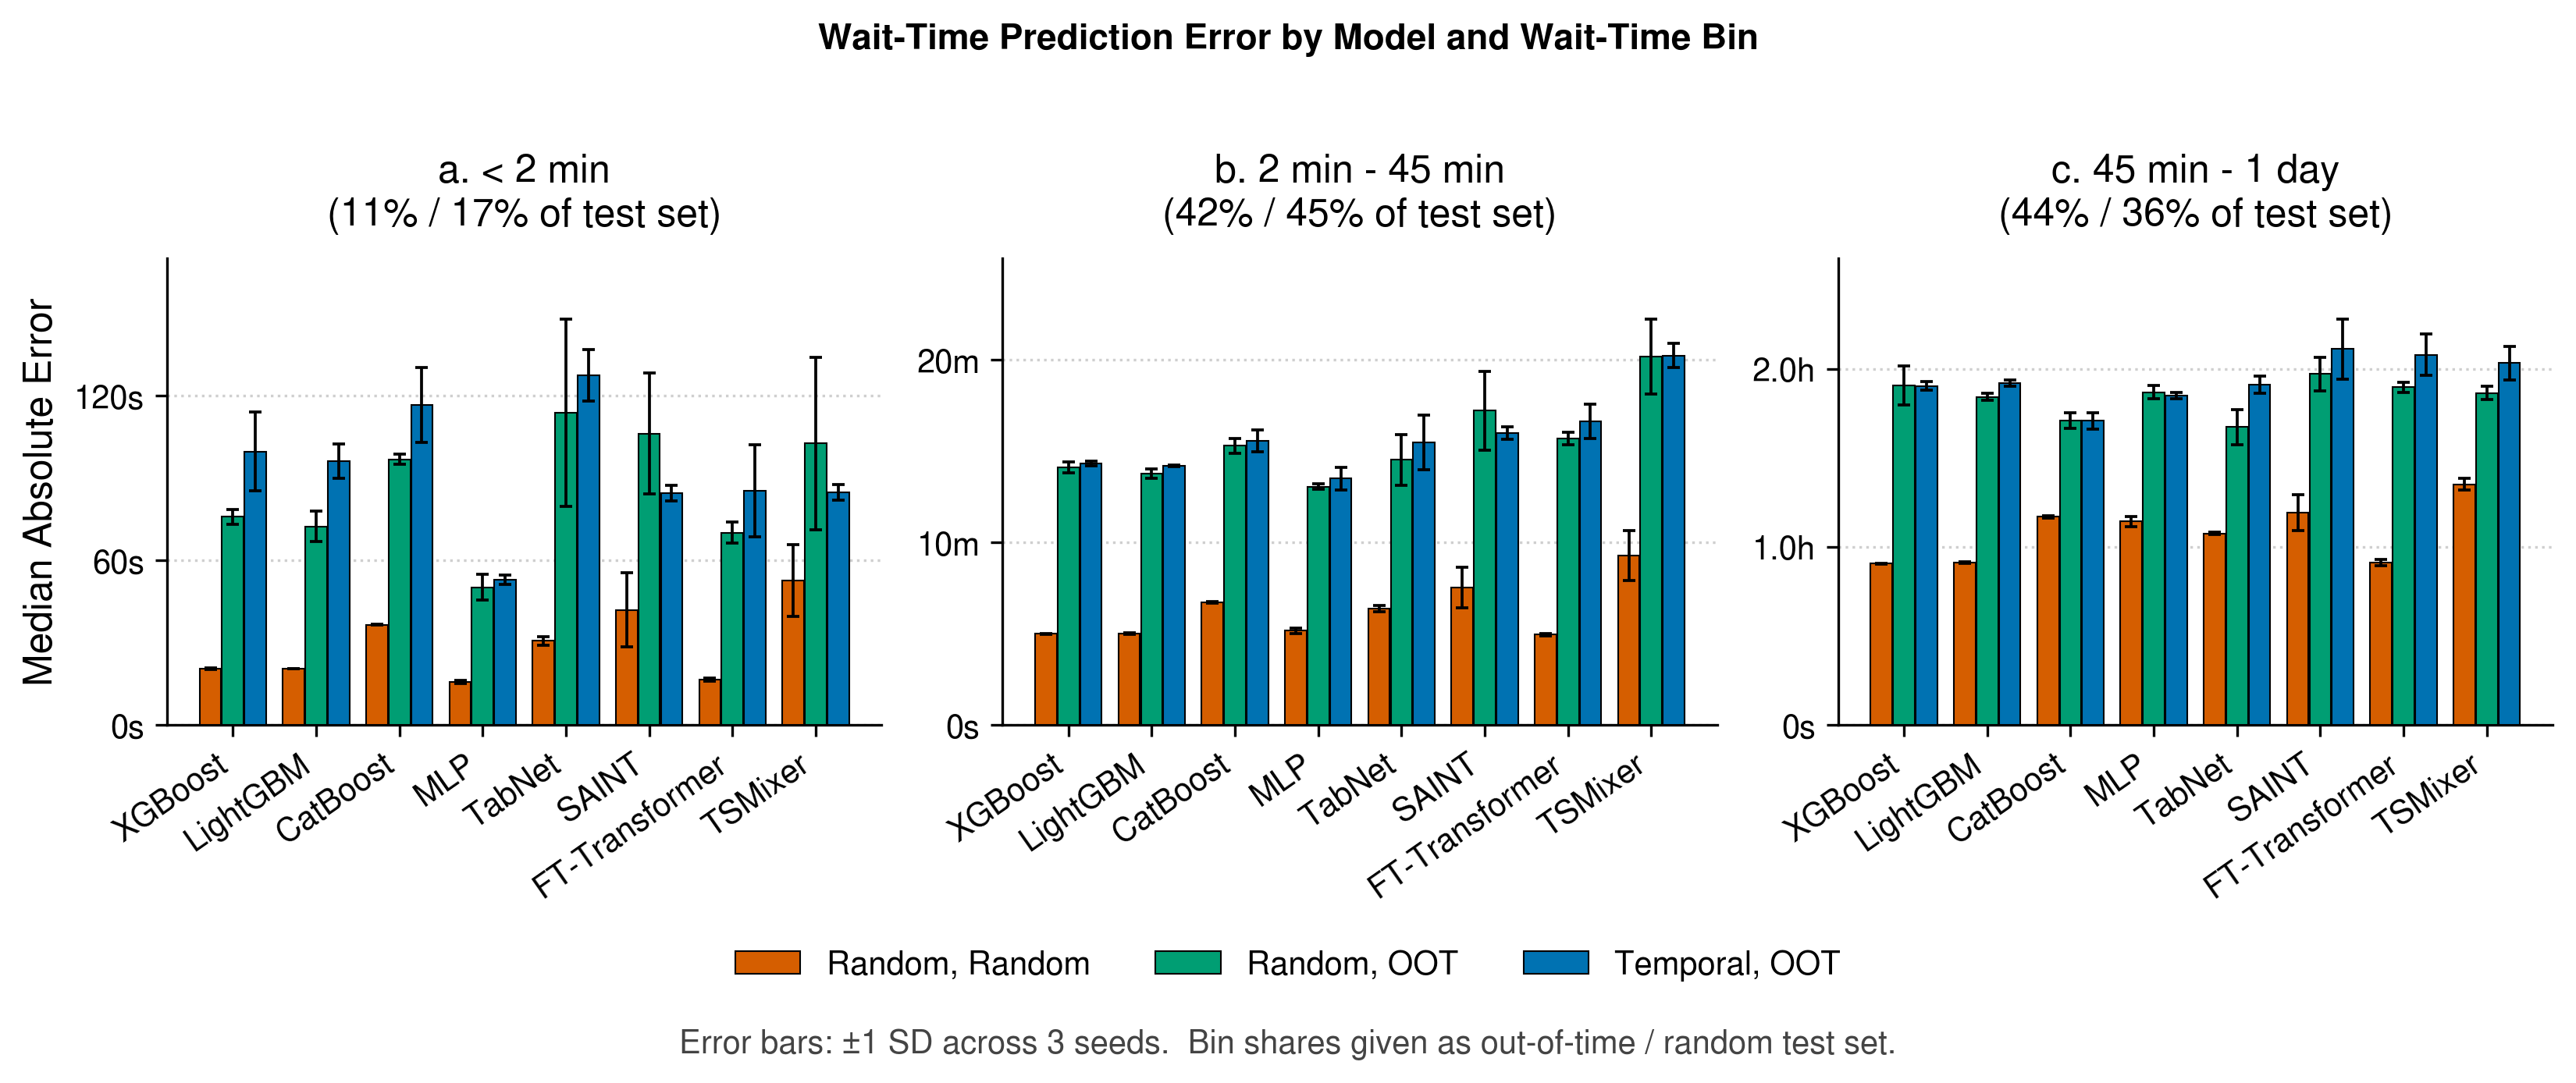

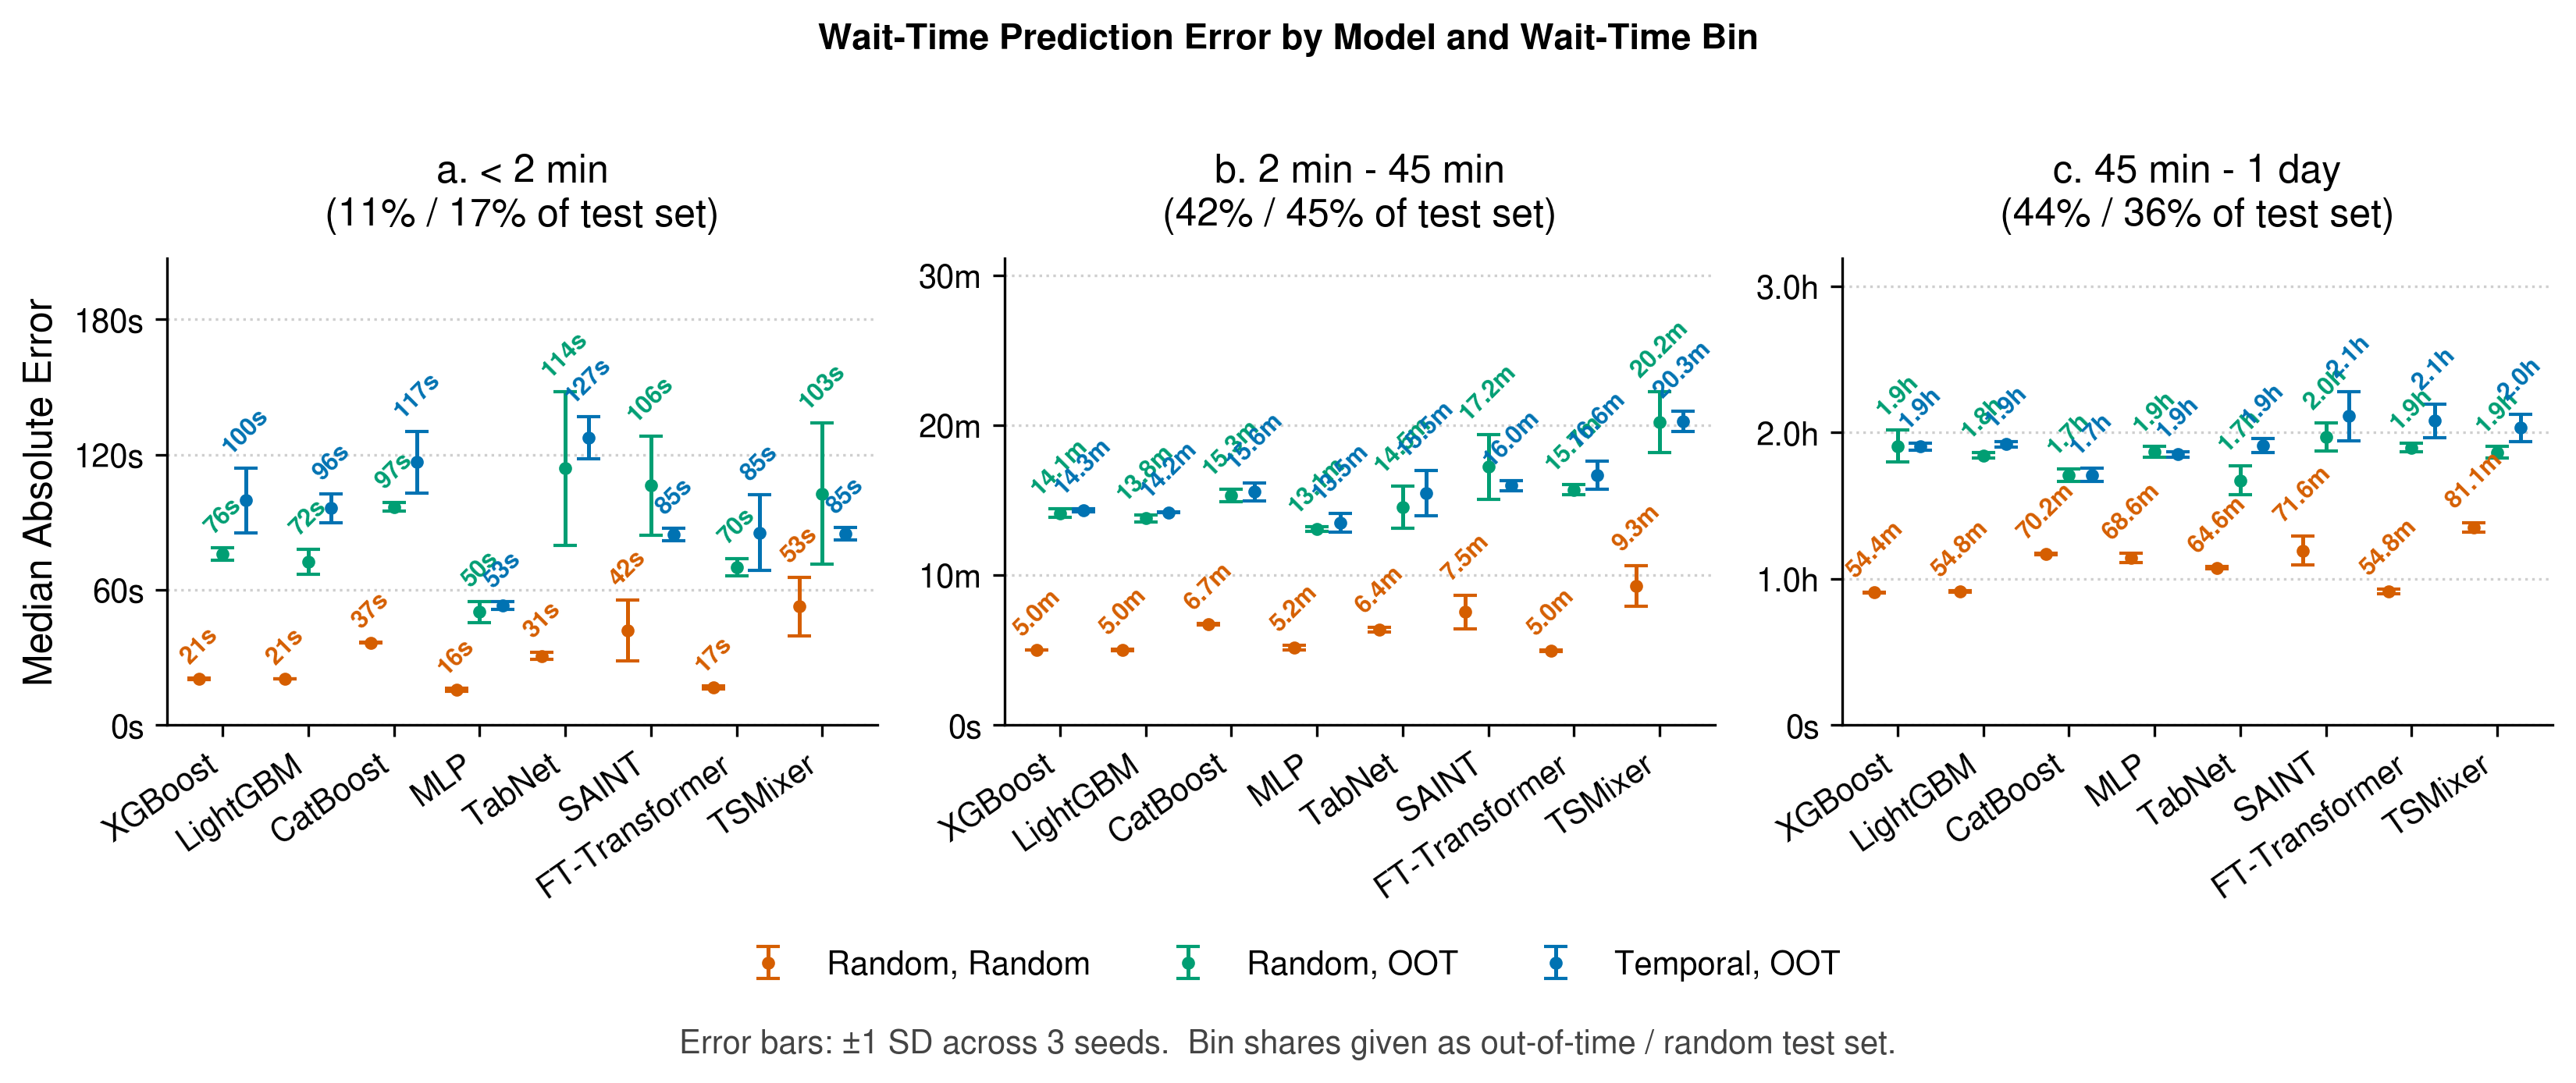

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def _clean_wait(idx):
  """Test-set wait times in seconds, for the bin shares in the panel titles."""
  y = np.asarray(wait_sv[idx], dtype=np.float64).ravel()
  y = y[~np.isnan(y)]
  # Auto-detect log-transformed wait times (e.g., log1p seconds max out ~10-15)
  if y.max() < 25.0:
    y = np.expm1(y)
  # Auto-detect millisecond wait times (e.g., values in 1e6+)
  if np.median(y) > 100000:
    y = y / 1000.0
  return y


# Three series, two test populations: the out-of-time set (temporal arm, and the random
# arm's "oot." block) and the random arm's own random test set. The same wait-time bin
# holds a different share of each; the titles show both when they disagree.
y_by_split = {"temporal_oot": _clean_wait(TEST_IDX["temporal"]),
              "random_random": _clean_wait(TEST_IDX["random"]),
              "random_oot": _clean_wait(TEST_IDX["oot"])}
y_test_raw = y_by_split["temporal_oot"]
global_median_wait = float(np.median(y_test_raw))

print(f"Test samples: out-of-time {len(y_by_split['temporal_oot']):,} | "
      f"random test set {len(y_by_split['random_random']):,}")
print(
    f"Wait range: {y_test_raw.min():.1f}s to {y_test_raw.max():.1f}s | Global"
    f" Median: {global_median_wait:.1f}s ({global_median_wait/60:.1f}m)"
)

# 2. Figure styling
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": "Nimbus Sans",
        "font.size": 10,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.titlesize": 12,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "primary": "#0072B2",  # Temporal split
    "secondary": "#D55E00",  # Random split, own random test set
    "tertiary": "#009E73",   # Random split, out-of-time test set
    "baseline": "#222222",  # Baseline contrast line
}

# Error bins are the queueing REGIMES recovered by the lognormal-mixture fit on the
# FermiGrid wait distribution (data-analysis.ipynb, cell `fgmix`), not round numbers.
# The fitted components have medians 28 s / 779 s / 2.50 h, and one component
# overtakes the next at 106 s and 2,857 s; those crossovers round to 2 min and 45 min.
# Each bin is therefore a distinct queueing mechanism rather than an arbitrary cut:
#   inst -- matched into an already-idle pilot slot
#   turn -- waiting for an occupied slot to turn over
#   prov -- waiting for new pilot provisioning
#   park -- beyond the 1 d cap: NOT a fitted component, just the tail past the
#           fit population, kept separate so its ~20x larger errors do not swamp prov
BINS = [
    ("a. < 2 min", "median_ae_inst", "mae_inst", (0, 120), "s"),
    ("b. 2 min - 45 min", "median_ae_turn", "mae_turn", (120, 2700), None),
    ("c. 45 min - 1 day", "median_ae_prov", "mae_prov", (2700, 86400), None),
    ("d. > 1 day", "median_ae_park", "mae_park", (86400, None), None),
]


def _dur(s, min_unit=5400, unit=None, minute_decimals=0):
  """Duration label. `minute_decimals` adds decimals to minute values -- used for the
  bar labels, so close bars stay distinguishable; the axis ticks keep whole minutes."""
  if s <= 0:
    return "0s"
  if unit == "s":          # forced, e.g. the sub-2-minute panel
    return f"{s:.0f}s"
  if s < 60:
    return f"{s:.0f}s"
  if s < min_unit:
    return f"{s / 60:.{minute_decimals}f}m"
  if s < 86400:
    return f"{s / 3600:.1f}h"
  return f"{s / 86400:.1f}d"


def _nice_step(vmax):
  for step in (
      30,
      60,
      120,
      300,
      600,
      900,
      1800,
      3600,
      7200,
      10800,
      21600,
      43200,
  ):
    if vmax / step <= 5:
      return step
  return 86400


models = df_wait.index.tolist()
x = np.arange(len(models))
BAR_W = 0.26   # three bars (or points) per model, at the 0.27 shifts in SERIES

# The >1 d row is computed and stored by reg_metrics, but not plotted: it is the
# outlier tail beyond the mixture fit's population rather than a queueing regime,
# and its ~2-day errors would compress the three real regimes into the baseline.
PLOT_BINS = [b for b in BINS if b[2] != "mae_park"]

# Draw the "predict the global median for everything" reference line?
# It sits far above the model errors in the short bins, so it dominates
# the y-scale when shown.
SHOW_BASELINE = False


def _sd_descriptor(df):
  """What the error bars on this split's line actually represent.

  A bar is +/- 1 SD across seeds, so it exists only where more than one seed ran and
  has length only where the seeds diverged. Stating "+/- 1 SD across seeds" flatly
  would claim a measurement for every point, so the three cases stay distinct.
  """
  ns = (df["n_seeds"].values.astype(float) if "n_seeds" in df
        else np.ones(len(df)))
  ns = np.where(np.isfinite(ns), ns, 0.0)
  measured = ns > 1
  levels = sorted({int(n) for n in ns[measured]})
  n_present = int(np.isfinite(df["r2_log"].values).sum()) if "r2_log" in df else len(df)
  if not measured.any():
    return "single seed; spread not measured"
  if measured.sum() == n_present and len(levels) == 1:
    return f"±1 SD across {levels[0]} seeds"
  return (f"±1 SD across seeds; "
          f"{int(measured.sum())}/{n_present} models multi-seed")


# (key, frame, colour, legend stem, metric prefix, x shift). Same order as the
# failure / fault-attribution charts. Temporal and Random, OOT are scored on the same
# out-of-time jobs (the random arm's "oot." block); Random, Random on the random arm's
# own test set.
SERIES = [
    ("random_random", df_rand, COLORS["secondary"], "Random, Random", "", -0.27),
    ("random_oot", df_rand, COLORS["tertiary"], "Random, OOT", "oot.", 0.0),
    ("temporal_oot", df_wait, COLORS["primary"], "Temporal, OOT", "", 0.27),
]

# "median AE" lives on the y-axis and the error-bar meaning in the footnote, so the
# legend carries only the split name. The descriptor is repeated per entry only when
# the two splits genuinely differ -- e.g. one at 3 seeds and the other at 2.
_desc = {s: _sd_descriptor(df_s) for s, df_s, *_ in SERIES}
_shared_desc = (next(iter(_desc.values())) if len(set(_desc.values())) == 1 else None)
_labels = {s: stem if _shared_desc else f"{stem} ({_desc[s]})"
           for s, _, _, stem, *_ in SERIES}


def plot_bins(style, out_path):
  """One figure, one panel per wait-time bin. Two designs, drawn one under the other
  for comparison:
    "bar"   -- grouped bars with error bars, no value labels (24 bars per panel leave
               no room for them);
    "point" -- a marker with error bars per series, labelled diagonally above."""
  fig, axes = plt.subplots(1, len(PLOT_BINS), figsize=(3.7 * len(PLOT_BINS), 3.8),
                           dpi=300)
  split_shares = False       # set when any panel's two shares differ enough to show

  for ax, (label, med_k, mean_k, (lo, hi), unit) in zip(axes, PLOT_BINS):
    _tops, _shares = [], {}

    for split_name, df_s, colr, stem, mpref, xshift in SERIES:
      med = df_s[mpref + med_k].values.astype(float)
      _sd = (df_s[mpref + med_k + "__sd"].values.astype(float)
             if (mpref + med_k + "__sd") in df_s else np.full(len(x), np.nan))
      yerr = np.where(np.isfinite(_sd), _sd, 0.0)

      ys = y_by_split[split_name]
      msk = (ys >= lo) & (ys < hi) if hi is not None else (ys >= lo)
      _shares[split_name] = float(msk.mean()) if msk.size else 0.0

      # Median AE only. The wait distribution is heavy-tailed -- mean AE in these bins
      # runs 2-6x the median -- so the mean describes the tail rather than the typical
      # job, and plotting both invited reading the gap as a model property when it is
      # a property of the target.
      if style == "bar":
        ax.bar(x + xshift, med, BAR_W, yerr=yerr, color=colr, edgecolor="black",
               linewidth=0.5,
               error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
               label=_labels[split_name], zorder=3)
      else:
        ax.errorbar(x + xshift, med, yerr=yerr, marker="o", linestyle="none",
                    markersize=3, capsize=3.5, elinewidth=1.2, color=colr,
                    label=_labels[split_name], zorder=4)
        for i, m_val in enumerate(med):
          if not np.isfinite(m_val):
            continue
          # Diagonal and centred over the point, bottom just above its error bar.
          ax.annotate(_dur(m_val, unit=unit, minute_decimals=1),
                      (x[i] + xshift, m_val + yerr[i]), textcoords="offset points",
                      xytext=(0, 3), ha="center", va="bottom", rotation=45,
                      rotation_mode="default", fontsize=7.5, color=colr,
                      fontweight="bold", zorder=5)

      _hi = med + yerr
      _tops.append(_hi[np.isfinite(_hi)])
      _tops.append(med[np.isfinite(med)])

    # Baseline error: median absolute error when predicting the global median.
    msk_b = ((y_test_raw >= lo) & (y_test_raw < hi) if hi is not None
             else (y_test_raw >= lo))
    base_ae = (float(np.median(np.abs(y_test_raw[msk_b] - global_median_wait)))
               if msk_b.any() else 0.0)

    _extra = [np.array([base_ae], dtype=float)] if SHOW_BASELINE else []
    _finite = np.concatenate(_tops + _extra) if (_tops or _extra) else np.array([])
    # Headroom: the point design's labels sit above the highest error bar.
    top = (float(_finite.max()) if _finite.size else 1.0) * (1.15 if style == "bar" else 1.4)
    if not np.isfinite(top) or top <= 0:
      top = 1.0
    ax.set_ylim(0, top)

    step = _nice_step(top)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _, u=unit: _dur(v, 3600, unit=u))
    )

    # Two populations' shares (out-of-time / random test set), named in the footnote.
    _a, _b = _shares["temporal_oot"], _shares["random_random"]
    if abs(_a - _b) < 0.01:
      _share_txt = f"{_a:.0%} of test set"
    else:
      _share_txt = f"{_a:.0%} / {_b:.0%} of test set"
      split_shares = True
    ax.set_title(f"{label}\n({_share_txt})", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha="right")
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

  axes[0].set_ylabel("Median Absolute Error")

  # Collect legend handles uniquely across all subplots
  handles_dict = {}
  for ax in axes:
    h_list, l_list = ax.get_legend_handles_labels()
    for h, l in zip(h_list, l_list):
      if l not in handles_dict:
        handles_dict[l] = h

  fig.legend(
      handles_dict.values(),
      handles_dict.keys(),
      loc="lower center",
      ncol=len(handles_dict),
      frameon=False,
      bbox_to_anchor=(0.5, -0.08),
  )

  # Kept short: bbox_inches="tight" widens the saved figure to fit this line, so a
  # note wider than the panels leaves empty margins either side of them.
  _notes = []
  if _shared_desc:
    _notes.append(f"Error bars: {_shared_desc}")
  if split_shares:
    _notes.append("Bin shares given as out-of-time / random test set")
  if _notes:
    fig.text(0.5, -0.1, ".  ".join(_notes) + ".", ha="center", va="top",
             fontsize=10, color="#444444")

  fig.suptitle(
      f"Wait-Time Prediction Error by Model and Wait-Time Bin",
      y=1.03,
      fontsize=11,
      fontweight="bold",
  )

  os.makedirs("output", exist_ok=True)
  plt.tight_layout()
  plt.savefig(out_path, bbox_inches="tight")
  plt.show()


plot_bins("bar", "output/wait_error_by_bin.pdf")
plot_bins("point", "output/wait_error_by_bin_points.pdf")